# POC Model
- Initial stock ranking model within-portfolio

## Things to Test
- Which response variable and model structure?
    - Structure
        - Simple saturated model with 1 Train and Test (Up to 2024, 2024 to present)
    - Types
        - Quantile rank model
        - Lambda rank model
        - Regression Model (_tweedie or weighted MSE_)
- CV Structure
    - Test purged and embargoed 3/4/5-Fold Cross Validation
    - Compare errors and generalization vs. simple Train/Test

- Variable Selection
    - Based on SHAP and temporal signal consistency

In [1]:
%pip install matplotlib
%pip install xgboost==3.0.2

import numpy as np
import pandas as pd
import xgboost as xgb

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/150.0 MB 6.1 MB/s eta 0:00:25
    --------------------------------------- 3.1/150.0 MB 8.5 MB/s eta 0:00:18
   - -------------------------------------- 5.0/150.0 MB 9.1 MB/s eta 0:00:16
   -- ------------------------------------- 8.1/150.0 MB 10.6 MB/s eta 0:00:14
   --- ------------------------------------ 12.8/150.0 MB 13.5 MB/s eta 0:00:11
   ---- ----------------------------------- 17.0/150.0 MB 14.6 MB/s eta 0:00:10
   ----- ---------------------------------- 21.2/150.0 MB 15.6 MB/s eta 0:00:09
   ------ --------------------------------- 26.0/150.0 MB 16.4 MB/s eta 0:00:08
   -------- ------------------------------- 31.5/150.0 MB 17.7 MB/s eta 0:00:07
   ---------- ----------------------------- 37.7/150.0 MB 19.1 MB/s eta 0:00:06
   ----------- ---------------------------- 41.9/150.0 MB 19.3 MB/s et

In [35]:
df = pd.read_parquet('../data/processed/modeling_dataset_28d.parquet')

In [36]:
fred_features = [
    'sector', 'industry', 'DFF', 'DGS10', 'DGS2', 'T10Y2Y', 'CPIAUCSL',
    'CPILFESL', 'PCEPI', 'GDP', 'GDPC1', 'INDPRO', 'UNRATE', 'PAYEMS',
    'ICSA', 'UMCSENT', 'RSXFS', 'VIXCLS', 'DCOILWTICO', 'M2SL', 'TOTALSL'
]

rank_features = [col for col in df.columns if "rank" in col]

zscore_features = [col for col in df.columns if col.endswith('_zscore')]

quintile_features = [col for col in df.columns if col.endswith('_quintile')]


In [37]:
modeling_features = fred_features + rank_features + zscore_features + quintile_features

In [38]:
modeling_features

['sector',
 'industry',
 'DFF',
 'DGS10',
 'DGS2',
 'T10Y2Y',
 'CPIAUCSL',
 'CPILFESL',
 'PCEPI',
 'GDP',
 'GDPC1',
 'INDPRO',
 'UNRATE',
 'PAYEMS',
 'ICSA',
 'UMCSENT',
 'RSXFS',
 'VIXCLS',
 'DCOILWTICO',
 'M2SL',
 'TOTALSL',
 'open_rank',
 'high_rank',
 'low_rank',
 'close_rank',
 'volume_rank',
 'market_cap_rank',
 'enterprise_value_rank',
 'trailing_pe_rank',
 'forward_pe_rank',
 'peg_ratio_rank',
 'price_to_book_rank',
 'price_to_sales_rank',
 'enterprise_to_revenue_rank',
 'enterprise_to_ebitda_rank',
 'profit_margin_rank',
 'operating_margin_rank',
 'gross_margin_rank',
 'roe_rank',
 'roa_rank',
 'revenue_growth_rank',
 'earnings_growth_rank',
 'total_cash_rank',
 'total_debt_rank',
 'debt_to_equity_rank',
 'current_ratio_rank',
 'quick_ratio_rank',
 'book_value_rank',
 'revenue_per_share_rank',
 'earnings_per_share_rank',
 'dividend_rate_rank',
 'dividend_yield_rank',
 'payout_ratio_rank',
 'beta_rank',
 'shares_outstanding_rank',
 'float_shares_rank',
 'held_percent_insiders_r

### Generate train, test, and quintile target

In [47]:
target = "target_28d"

df = df[df[target].notna()].copy()

# Convert categorical columns to category dtype
categorical_features = ['sector', 'industry']
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Time-based split (1-month embargo for test)
train = df[df['date'] < '2024-01-01']
test = df[df['date'] >= '2024-02-01']

## 1) Quantile Rank: will a stock be in top 20% of returns?

In [12]:
# XGBoost classifier
base_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    eval_metric="mlogloss",
    n_estimators=50,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    enable_categorical=True,
    random_state=42
)

base_model.fit(
    train[modeling_features],
    train[target]
)

test['pred'] = base_model.predict(test[modeling_features])



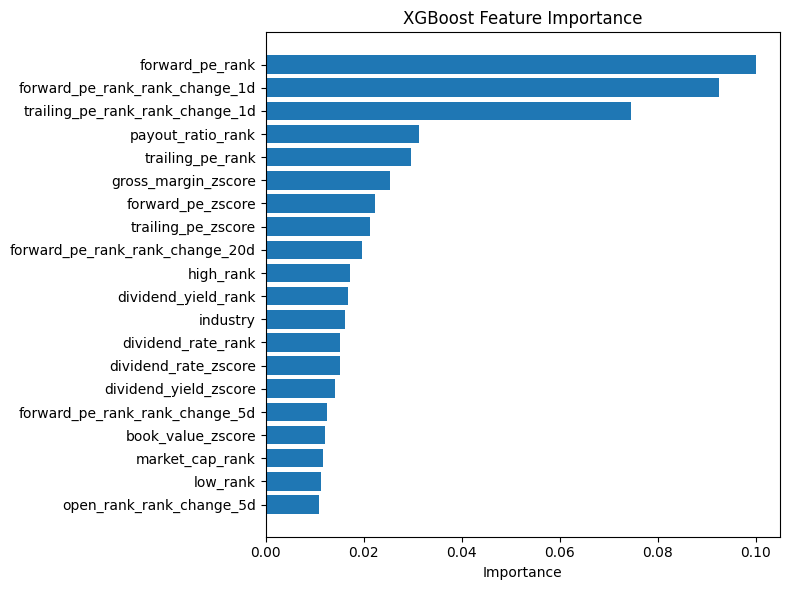

In [13]:
import matplotlib.pyplot as plt

feature_importance_df = pd.DataFrame({
    "feature": modeling_features,
    "importance": base_model.feature_importances_
}).sort_values("importance", ascending=False).head(20)

# Sort for plotting
feature_importance_df = feature_importance_df.sort_values(
    "importance", ascending=True
)

plt.figure(figsize=(8, 6))
plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["importance"]
)
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()


### Evaluate performance when rebalancing stocks monthly

In [14]:
# Create year-month column for grouping
test['year_month'] = test['date'].dt.to_period('M')

# Initialize results
monthly_returns = []

for month in test['year_month'].unique():
    month_data = test[test['year_month'] == month].copy()
    
    # Get first and last date of the month
    month_dates = month_data['date'].sort_values()
    first_date = month_dates.iloc[0]
    last_date = month_dates.iloc[-1]
    
    # Get predictions at the BEGINNING of month (first date)
    first_day_data = month_data[month_data['date'] == first_date].copy()
    
    # Select stocks to long and short based on first-day predictions
    long_stocks = first_day_data[first_day_data['pred'] == 4]['ticker'].unique()
    short_stocks = first_day_data[first_day_data['pred'] == 0]['ticker'].unique()
    
    # Calculate holding period returns for each stock
    # Return = (price_end - price_start) / price_start
    long_rets = []
    for ticker in long_stocks:
        ticker_data = month_data[month_data['ticker'] == ticker].sort_values('date')
        if len(ticker_data) >= 2:
            start_price = ticker_data.iloc[0]['close']
            end_price = ticker_data.iloc[-1]['close']
            ret = (end_price - start_price) / start_price
            long_rets.append(ret)
    
    # short_rets = []
    # for ticker in short_stocks:
    #     ticker_data = month_data[month_data['ticker'] == ticker].sort_values('date')
    #     if len(ticker_data) >= 2:
    #         start_price = ticker_data.iloc[0]['close']
    #         end_price = ticker_data.iloc[-1]['close']
    #         ret = (end_price - start_price) / start_price
    #         short_rets.append(ret)
    
    # Equal-weighted portfolio returns
    long_ret = np.mean(long_rets) if len(long_rets) > 0 else 0
    # short_ret = np.mean(short_rets) if len(short_rets) > 0 else 0
    # ls_ret = long_ret - short_ret
    
    monthly_returns.append({
        'month': month,
        'long_return': long_ret,
        # 'short_return': short_ret,
        # 'ls_return': ls_ret,
        'n_long': len(long_rets),
        # 'n_short': len(short_rets),
        'days_held': (last_date - first_date).days
    })

# Convert to DataFrame
returns_df = pd.DataFrame(monthly_returns)

print("Monthly Long-Short Performance:")
print(returns_df)

# Summary statistics
print("\n=== Performance Summary ===")
print(f"Total Months: {len(returns_df)}")
print(f"Mean Monthly Return: {returns_df['long_return'].mean():.4f}")
print(f"Median Monthly Return: {returns_df['long_return'].median():.4f}")
print(f"Std Dev: {returns_df['long_return'].std():.4f}")
print(f"Sharpe Ratio (annualized): {returns_df['long_return'].mean() / returns_df['long_return'].std() * np.sqrt(12):.2f}")
print(f"Win Rate: {(returns_df['long_return'] > 0).mean():.2%}")
print(f"Max Monthly Return: {returns_df['long_return'].max():.4f}")
print(f"Min Monthly Return: {returns_df['long_return'].min():.4f}")

# Cumulative returns
returns_df['cumulative_return'] = (1 + returns_df['long_return']).cumprod() - 1
print(f"\nCumulative Return: {returns_df['cumulative_return'].iloc[-1]:.2%}")

# Annualized metrics
annualized_return = returns_df['long_return'].mean() * 12
print(f"\nAnnualized Return: {annualized_return:.2%}")
print(f"Average Holding Period: {returns_df['days_held'].mean():.1f} days")


Monthly Long-Short Performance:
      month  long_return  n_long  days_held
0   2024-02     0.074896     216         28
1   2024-03     0.027709     219         27
2   2024-04    -0.039324     228         29
3   2024-05     0.059917     228         30
4   2024-06     0.025285     241         25
5   2024-07     0.021934     239         30
6   2024-08     0.050782     239         29
7   2024-09     0.081677     265         27
8   2024-10     0.023648     263         30
9   2024-11     0.071737     195         28
10  2024-12    -0.031764     169         24

=== Performance Summary ===
Total Months: 11
Mean Monthly Return: 0.0333
Median Monthly Return: 0.0277
Std Dev: 0.0405
Sharpe Ratio (annualized): 2.85
Win Rate: 81.82%
Max Monthly Return: 0.0817
Min Monthly Return: -0.0393

Cumulative Return: 42.29%

Annualized Return: 39.98%
Average Holding Period: 27.9 days


## 2) Lambda Rank Model

In [ ]:
# Sort train and test by date to create groups
train = train.sort_values("date").reset_index(drop=True)
test = test.sort_values("date").reset_index(drop=True)

In [49]:
y_train = train["return_t+28"]
X_train = train[modeling_features]

dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)

# Number of stocks per date
group_train = train.groupby("date").size().values
dtrain.set_group(group_train)

In [50]:
# XGBoost Rank model
params = {
    "objective": "rank:pairwise",
    "eval_metric": "ndcg",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "colsample_bylevel": 0.8,
    "tree_method": "hist",
    "seed": 42
}

rank_model = xgb.train(
    params,
    dtrain,
    num_boost_round=50
)

test['pred_rank'] = rank_model.predict(test[modeling_features])

TypeError: ('Expecting data to be a DMatrix object, got: ', <class 'pandas.DataFrame'>)